# Basis state probabilities of small lattices

In [1]:
import os
import sys
from pathlib import Path
from functools import partial
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import eigh, eigvalsh
import rustworkx as rx
import h5py
import jax
import jax.numpy as jnp
from jax.sharding import PartitionSpec, NamedSharding
from jax.experimental.ode import odeint
from qiskit.quantum_info import SparsePauliOp
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.parameters import Parameters
from skqd_z2lgt.extensions import denoising, perturbation_2q
from skqd_z2lgt.circuits import make_plaquette_circuits
from skqd_z2lgt.sqd import sqd
from skqd_z2lgt.mwpm import minimum_weight_link_state
from skqd_z2lgt.extensions import perturbation_2q
from skqd_z2lgt.utils import read_bits
from skqd_z2lgt.tasks.common import make_dual_lattice
from skqd_z2lgt.jax_experimental_sparse_linalg import lobpcg_standard
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from unitary_krylov import make_hvec, make_trotter_uvec, integrate, simulate, sample, exact_diag, compute_gen_eigvals

logging.basicConfig(level=logging.INFO)
os.environ['CUDA_VISIBLE_DEVICES'] = '1,2,3,6'
jax.config.update('jax_enable_x64', True)

data_dir = Path('/data/iiyama/2dz2/unitary_krylov')

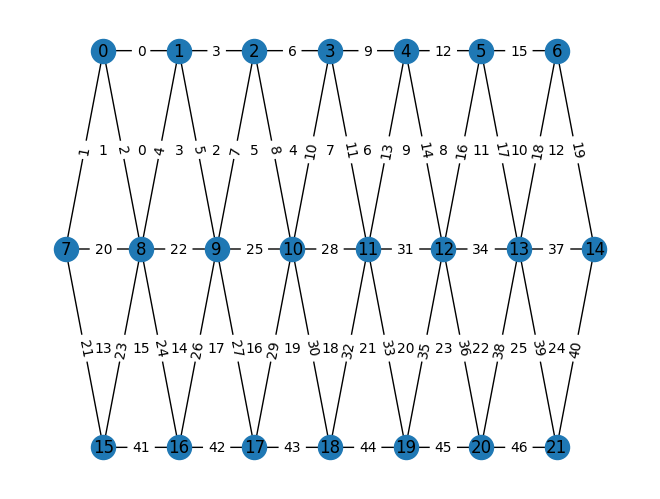

In [2]:
config = '''
 * * * * * * *
* * * * * * * *
 * * * * * * *
'''
# config = '''
#  * *
# * * *
# '''
lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [3]:
plaquette_energy = 3.
charged_vertices = [7, 14]

base_link_state = minimum_weight_link_state(charged_vertices, lattice)
print(np.nonzero(base_link_state[::-1])[0])
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)

[20 22 25 28 31 34 37]


In [4]:
hvec = make_hvec(hamiltonian)
xmat = np.zeros((2 ** nplaq, 1), dtype=np.complex128)
xmat[0, 0] = 1.
# xmat[1 << np.arange(nplaq), 1] = 1. / np.sqrt(nplaq)
eigvals_exact, eigvecs_exact, _ = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)
eigvals_exact *= -1.

INFO:2025-12-05 12:14:03,131:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [5]:
probs = np.square(np.abs(eigvecs_exact[:, 0]))
sort_idx = np.argsort(probs)[::-1]
sorted_states = (sort_idx[:, None] >> np.arange(nplaq)[::-1]) % 2
sorted_probs = probs[sort_idx]

In [6]:
for state, prob in zip(sorted_states[:100], sorted_probs):
    link_state = base_link_state.copy()
    plaqs = np.nonzero(state[::-1])[0]
    for plaq in plaqs:
        excitation = np.zeros_like(link_state)
        excitation[::-1][lattice.plaquette_links(plaq)] = 1
        link_state ^= excitation
    links = np.nonzero(link_state[::-1])[0]
    print(links, plaqs, prob)

[20 22 25 28 31 34 37] [] 2.942280845334955e-05
[10 11 20 22 25 31 34 37] [7] 1.8138673639962864e-05
[20 22 25 30 31 32 34 37] [18] 1.8138673565604884e-05
[13 14 20 22 25 28 34 37] [9] 1.8134113596574668e-05
[20 22 25 28 33 34 35 37] [20] 1.8134113586610667e-05
[20 22 27 28 29 31 34 37] [16] 1.8134113581360442e-05
[ 7  8 20 22 28 31 34 37] [5] 1.8134113539277755e-05
[ 4  5 20 25 28 31 34 37] [3] 1.8033981795083104e-05
[20 24 25 26 28 31 34 37] [14] 1.803398177231911e-05
[20 22 25 28 31 36 37 38] [22] 1.80339814373569e-05
[16 17 20 22 25 28 31 37] [11] 1.8033981431003444e-05
[21 22 23 25 28 31 34 37] [13] 1.5317381203963238e-05
[ 1  2 22 25 28 31 34 37] [1] 1.5317380919566922e-05
[20 22 25 28 31 34 39 40] [24] 1.531738064789834e-05
[18 19 20 22 25 28 31 34] [12] 1.5317380645927422e-05
[10 11 13 14 20 22 25 34 37] [7 9] 1.1667143174486647e-05
[ 7  8 10 11 20 22 31 34 37] [5 7] 1.1667143147309033e-05
[20 22 27 29 30 31 32 34 37] [16 18] 1.1667143141077306e-05
[20 22 25 30 32 33 34 35 37] 

In [11]:
pert_states = perturbation_2q(np.empty((0, nplaq), dtype=np.uint8), dual_lattice)

In [12]:
pert_energy, pert_eigvec, _, hproj = sqd(hamiltonian, pert_states)
print(pert_energy - eigvals_exact[0])

INFO:skqd_z2lgt.sqd:3.580252 seconds to sort 17902 bitstrings
INFO:skqd_z2lgt.sqd:10.384373 seconds to diagonalize


17.102242826687288


In [13]:
delta_t = 0.06
trotter_uvec = make_trotter_uvec(hamiltonian, delta_t * 0.5)
skqd_samples = []
for num_steps in range(2, 18, 2):
    print(num_steps)
    samples = sample(trotter_uvec, nplaq, num_steps, 400_000)
    skqd_samples.append(samples)
skqd_samples_unique = jnp.unique(jnp.concatenate(skqd_samples, axis=0), axis=0)
skqd_states_unique = ((skqd_samples_unique[:, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)

2
4
6
8
10
12
14
16


In [14]:
all_states = np.unique(np.concatenate([pert_states, skqd_states_unique], axis=0), axis=0)
all_states.shape

(1714338, 26)

In [15]:
all_energy, all_eigvec, _, all_hproj = sqd(hamiltonian, all_states)
print(all_energy - eigvals_exact[0])

INFO:skqd_z2lgt.sqd:6.073288 seconds to sort 1714338 bitstrings
INFO:skqd_z2lgt.sqd:16.604315 seconds to diagonalize


13.36057052213178


In [4]:
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][[1, 5, 11, 16, 22, 26]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(1.)
jnp.linalg.eigh(hamiltonian.to_matrix())[0]

Array([-21.14304127, -20.34181614, -20.08957748, ...,  18.44331748,
        19.22995526,  19.3411709 ], dtype=float64)

In [ ]:
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][[1, 6, 12, 17, 23, 26]] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(1.)
hvec = make_hvec(hamiltonian)

In [11]:
xmat = np.zeros((2 ** nplaq, 2), dtype=np.complex128)
xmat[1 << np.array([3, 5, 9, 11]), 0] = 1.
xmat[1 << np.arange(nplaq), 1] = 1. / np.sqrt(nplaq)
vals, vecs, _ = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)

In [12]:
vals[0]

Array(29.33650263, dtype=float64)

In [18]:
xmat[:, 0] @ hvec(xmat[:, 0])

Array(-22.+0.j, dtype=complex128)

In [19]:
ymat = np.zeros((2 ** nplaq, 2), dtype=np.complex128)
ymat[0, 0] = 1.
ymat[:, 0] @ hvec(ymat[:, 0])

Array(-28.+0.j, dtype=complex128)

In [12]:
probs = np.square(np.abs(vecs[:, 0]))
sort_idx = np.argsort(probs)[::-1]
sorted_states = (sort_idx[:, None] >> np.arange(nplaq)[::-1]) % 2
sorted_probs = probs[sort_idx]

In [13]:
for state, prob in zip(sorted_states, sorted_probs):
    print(np.nonzero(state[::-1])[0], prob)

[] 0.6503224154109936
[6] 0.01858816500736153
[9] 0.018566373738517158
[7] 0.01856637373851709
[3] 0.018546546132229093
[12] 0.018527215721871784
[10] 0.018527215721871777
[13] 0.01806294058070373
[8] 0.018045815551765005
[5] 0.018045815551764918
[2] 0.018044829119385788
[0] 0.01804482911938578
[4] 0.01802673044756949
[1] 0.018026730447569438
[14] 0.017578426969693486
[11] 0.017578426969693427
[6 9] 0.0011795906586695008
[6 7] 0.00117959065866949
[3 6] 0.0011777988489467277
[ 9 12] 0.0011740929476813555
[ 7 10] 0.0011740929476813404
[8 9] 0.0011332033089187297
[5 7] 0.001133203308918711
[2 3] 0.0011314141456940823
[0 3] 0.0011314141456940775
[12 13] 0.0011313686309442502
[10 13] 0.0011313686309442478
[12 14] 0.001090617171845708
[10 11] 0.0010906171718456955
[4 8] 0.0010892158247236463
[1 5] 0.0010892158247236368
[2 4] 0.0010891307120027016
[0 1] 0.0010891307120026964
[7 9] 0.0005357784579716363
[ 6 12] 0.0005352521069444203
[ 6 10] 0.0005352521069444197
[3 9] 0.0005351957697132281
[3 

In [2]:
config_30 = '''
   * *
  * * *
 * * * *
* * * * *
 * * * *
  * * *
   * *
'''

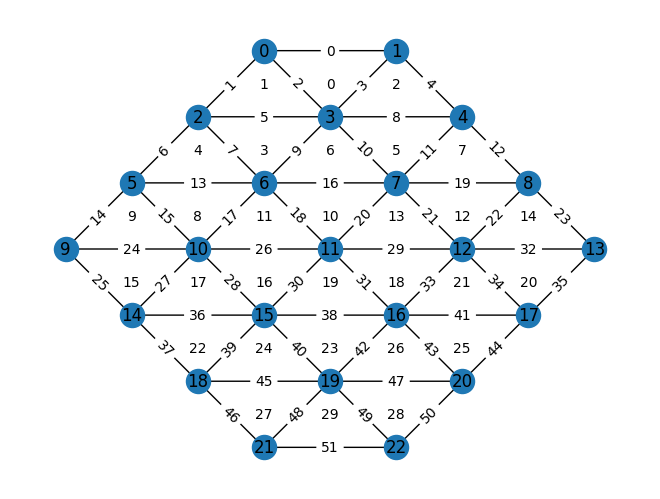

In [3]:
TriangularZ2Lattice(config_30).draw_graph();

## SKQD required samples

In [4]:
plaquette_energy = 1.
delta_t = 0.04
charged_vertices = [0, 21]

lattice = TriangularZ2Lattice(config_30)
base_link_state = minimum_weight_link_state(charged_vertices, lattice)
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)


In [5]:
pert_states = perturbation_2q(np.empty((0, nplaq), dtype=np.complex128), dual_lattice)

In [6]:
pert_states.shape

(404422, 30)

In [7]:
trotter_uvec = make_trotter_uvec(hamiltonian, delta_t * 0.5)
skqd_states = []
for num_steps in range(2, 18, 2):
    print(num_steps)
    samples = np.unique(sample(trotter_uvec, nplaq, num_steps, 100_000))
    skqd_states.append((samples[:, None] >> np.arange(nplaq)[::-1]) % 2)
skqd_states = np.unique(np.concatenate(skqd_states, axis=0), axis=0)

2


INFO:2025-12-04 15:40:26,263:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


4
6
8
10
12
14
16


In [8]:
skqd_states.shape

(123, 30)

In [10]:
np.unique(np.concatenate([pert_states, skqd_states], axis=0), axis=0).shape

(404423, 30)

In [ ]:
states = ((samples[:, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
sqd_energy, sqd_eigvec, sqd_states, hproj = sqd(hamiltonian, states)

INFO:skqd_z2lgt.sqd:0.771295 seconds to sort 49 bitstrings
INFO:skqd_z2lgt.sqd:4.206282 seconds to diagonalize


In [ ]:
sqd_energy

-55.284155645779954

In [ ]:
num_steps = 8
delta_t = 0.04
plaquette_energy = 1.
shots = 100_000
config = configs[-1]

dual_lattice = TriangularZ2Lattice(config).plaquette_dual()
nplaq = dual_lattice.num_plaquettes
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)
trotter_uvec = make_trotter_uvec(hamiltonian, delta_t * 0.5)
psi_sim = simulate(trotter_uvec, nplaq, num_steps)
cumprobs = np.cumsum(np.square(np.abs(psi_sim)), axis=1)
state_indices = []
for istep in range(1, num_steps + 1):
    rand = np.random.random(shots)
    state_indices.append(np.searchsorted(cumprobs[istep], rand))
state_indices = np.concatenate(state_indices)
state_indices = np.unique(state_indices)
states = ((state_indices[:, None] >> np.arange(nplaq)[::-1]) % 2).astype(np.uint8)
sqd_energy, sqd_eigvec, sqd_states, hproj = sqd(hamiltonian, states)

INFO:skqd_z2lgt.sqd:2.347222 seconds to sort 9425 bitstrings
INFO:skqd_z2lgt.sqd:8.008753 seconds to diagonalize


In [ ]:
sqd_energy

-41.494513616885094

In [ ]:
exact_eigvals[21]

array([-41.51749242, -36.651517  ])

## Coupling scan of basis state probabilities for a 3-plaquette system

In [63]:
config = '''
 * * *
* * * *
'''
lattice = TriangularZ2Lattice(config)
charged_vertices = [3, 6]
base_link_state = minimum_weight_link_state(charged_vertices, lattice)
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = lattice.num_plaquettes
ham = dual_lattice.make_hamiltonian(1.)
diag_mat = ham[:-nplaq].to_matrix()
nondiag_mat = ham[-nplaq:].to_matrix()
lambdas = np.linspace(0.1, 10.1, 101)
mats = np.tile(diag_mat[None, ...], (101, 1, 1)) + lambdas[:, None, None] * nondiag_mat[None, ...]
eigvals, eigvecs = np.linalg.eigh(mats)

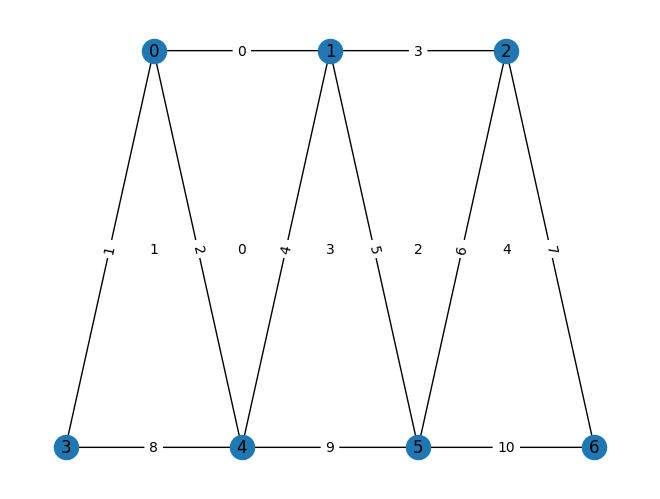

In [64]:
lattice.draw_graph();

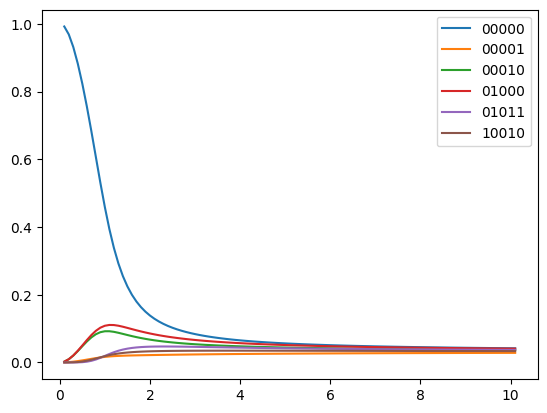

In [65]:
probs = np.square(np.abs(eigvecs[:, :, 0]))
fmt = '{:0%db}' % lattice.num_plaquettes
selected = [0, 1, 2, 8, 11, 18]
# plt.plot(lambdas, probs, label=[fmt.format(i) for i in range(probs.shape[1])])
plt.plot(lambdas, probs[:, selected], label=[fmt.format(i) for i in selected])
# plt.yscale('log')
plt.legend();

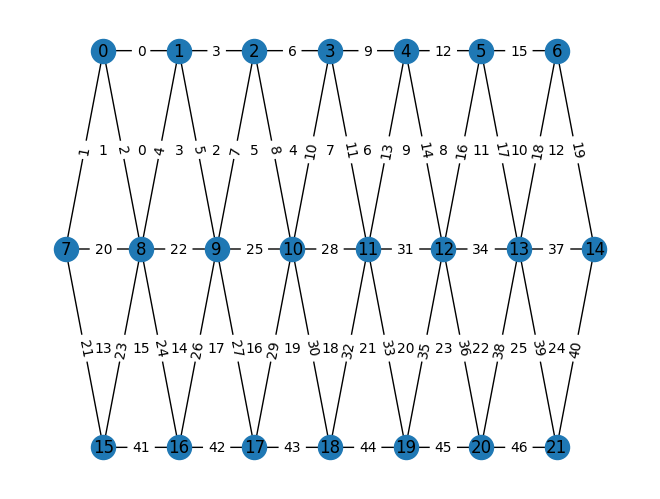

In [2]:
config = '''
 * * * * * * *
* * * * * * * *
 * * * * * * *
'''
# config = '''
#  * *
# * * *
# '''
lattice = TriangularZ2Lattice(config)
lattice.draw_graph();

In [3]:
charged_vertices = [7, 14]

base_link_state = minimum_weight_link_state(charged_vertices, lattice)
print(np.nonzero(base_link_state[::-1])[0])
dual_lattice = lattice.plaquette_dual(base_link_state)
nplaq = dual_lattice.num_plaquettes

[20 22 25 28 31 34 37]


In [4]:
lambdas = np.linspace(0.1, 10.1, 21)
probs = np.empty((21, 2 ** nplaq))
for ilmd, plaquette_energy in enumerate(lambdas):
    print(ilmd)
    hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)
    hvec = make_hvec(hamiltonian)
    xmat = np.zeros((2 ** nplaq, 1), dtype=np.complex128)
    xmat[0, 0] = 1.
    # xmat[1 << np.arange(nplaq), 1] = 1. / np.sqrt(nplaq)
    _, eigvecs_exact, _ = lobpcg_standard(lambda x: -hvec(x.T).T, xmat)
    probs[ilmd] = np.square(np.abs(eigvecs_exact[:, 0]))

0


INFO:2025-12-05 14:26:02,724:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [5]:
probs.shape

(21, 67108864)

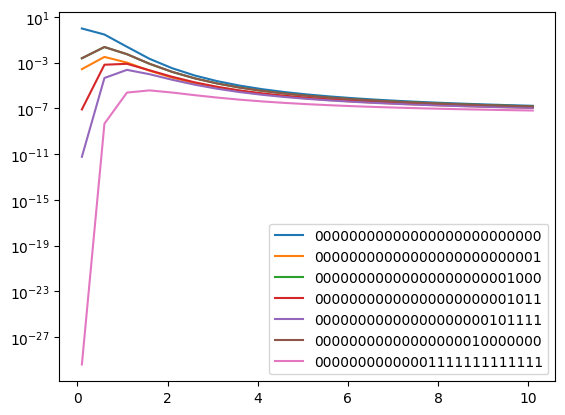

In [9]:
selected = [0, 1, 8, 11, 47, 128, 2 ** 13 - 1]
fmt = '{:0%db}' % nplaq
# plt.plot(lambdas, probs, label=[fmt.format(i) for i in range(probs.shape[1])])
plt.plot(lambdas[:], probs[:, selected], label=[fmt.format(i) for i in selected])
plt.yscale('log')
plt.legend();

In [10]:
lambdas

array([ 0.1,  0.6,  1.1,  1.6,  2.1,  2.6,  3.1,  3.6,  4.1,  4.6,  5.1,
        5.6,  6.1,  6.6,  7.1,  7.6,  8.1,  8.6,  9.1,  9.6, 10.1])

In [ ]:
sort_idx = np.argsort(probs[4])[::-1]
sorted_probs = probs[4, sort_idx]
prob_cumsum = np.cumsum(sorted_probs)
np.searchsorted(prob_cumsum, 0.9999)

np.int64(60183045)

In [13]:
np.searchsorted(prob_cumsum, 0.99)

np.int64(27645526)